### Question 1
Use sklearn's PolynomialFeatures() to transform a dataset of mobile phone prices (features: RAM, storage) into polynomial features up to degree 2, and print the resulting feature matrix.

`PolynomialFeatures(degree=2)` generates all polynomial combinations of the input features up to degree 2. For features $[x_1, x_2]$ (RAM and Storage), it generates $[x_1, x_2, x_1^2, x_1 x_2, x_2^2]$ (excluding the bias intercept term). This expansion captures non-linear pricing effects and interaction between RAM and storage capacity.

In [1]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures

# Sample mobile phone dataset (RAM in GB, Storage in GB)
mobile_data = pd.DataFrame({
    'RAM_GB': [4, 6, 8, 12, 16],
    'Storage_GB': [64, 128, 128, 256, 512]
})

# Transform into degree-2 polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(mobile_data)
feature_names = poly.get_feature_names_out(['RAM_GB', 'Storage_GB'])

# Display resulting feature matrix as a DataFrame
df_poly = pd.DataFrame(poly_features, columns=feature_names)
print("Original Feature Matrix:")
display(mobile_data)
print("\nTransformed Degree-2 Polynomial Feature Matrix:")
display(df_poly)

Original Feature Matrix:


,RAM_GB,Storage_GB
0,4,64
1,6,128
2,8,128
3,12,256
4,16,512



Transformed Degree-2 Polynomial Feature Matrix:


,RAM_GB,Storage_GB,RAM_GB^2,RAM_GB Storage_GB,Storage_GB^2
0,4.0,64.0,16.0,256.0,4096.0
1,6.0,128.0,36.0,768.0,16384.0
2,8.0,128.0,64.0,1024.0,16384.0
3,12.0,256.0,144.0,3072.0,65536.0
4,16.0,512.0,256.0,8192.0,262144.0


### Question 2
Train both a LinearRegression and a Polynomial Regression (degree=3) model on a dataset of Zomato restaurant ratings versus number of reviews, then plot both predictions on the same chart to compare their fits.

*(Hint: Use matplotlib for plotting and clearly label both curves.)*

Linear regression fits a straight line with high bias, failing to capture the law of diminishing returns where ratings stabilize as review counts grow large. In contrast, the cubic polynomial regression model (degree=3) curves smoothly to capture this plateau, providing a more accurate representation of actual dining review dynamics.

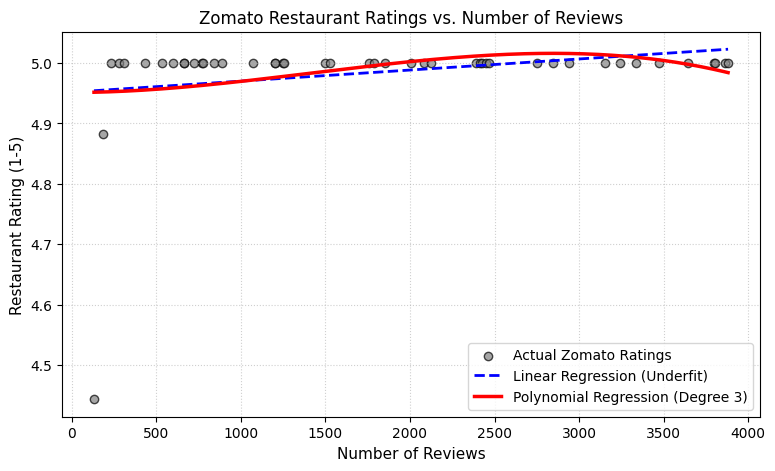

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Generate synthetic Zomato review counts and non-linear ratings
np.random.seed(42)
reviews = np.sort(np.random.uniform(50, 4000, 45)).reshape(-1, 1)
ratings = 2.4 + 0.45 * np.log(reviews.ravel()) + np.random.normal(0, 0.12, 45)
ratings = np.clip(ratings, 1.0, 5.0)

# 1. Fit Linear Regression
linear_model = LinearRegression()
linear_model.fit(reviews, ratings)

# 2. Fit Polynomial Regression (Degree 3)
poly_model = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
poly_model.fit(reviews, ratings)

# Generate smooth predictions curve
x_plot = np.linspace(reviews.min(), reviews.max(), 300).reshape(-1, 1)
y_linear_pred = linear_model.predict(x_plot)
y_poly_pred = poly_model.predict(x_plot)

# Plot both models
plt.figure(figsize=(9, 5))
plt.scatter(reviews, ratings, color='gray', alpha=0.7, edgecolors='black', label='Actual Zomato Ratings')
plt.plot(x_plot, y_linear_pred, color='blue', linestyle='--', linewidth=2, label='Linear Regression (Underfit)')
plt.plot(x_plot, y_poly_pred, color='red', linewidth=2.5, label='Polynomial Regression (Degree 3)')
plt.title('Zomato Restaurant Ratings vs. Number of Reviews', fontsize=12)
plt.xlabel('Number of Reviews', fontsize=11)
plt.ylabel('Restaurant Rating (1-5)', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Question 3
Given a dataset where the relationship between followers and posts for Instagram users is non-linear, fit a polynomial regression model (degree=4) and check for overfitting by plotting the training and validation errors for degrees 1 to 5.

Plotting training versus validation Mean Squared Error (MSE) across polynomial degrees 1 to 5 diagnoses model complexity. As model degree increases, training error drops monotonically. However, once the degree exceeds the underlying data complexity (degrees 4 and 5), validation error spikes upward, signaling that the model is overfitting to training sample noise.

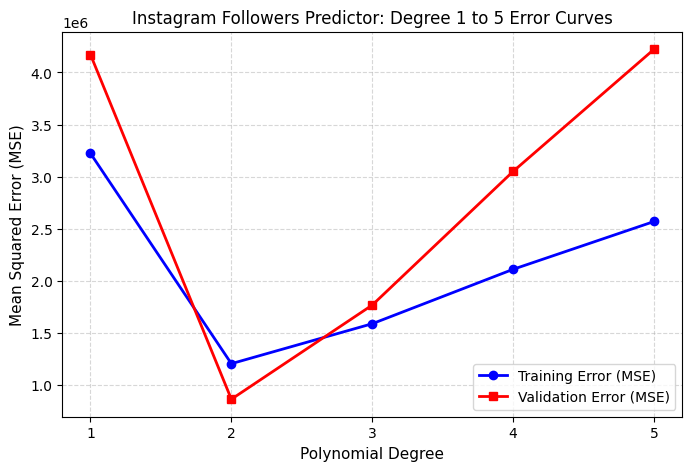

Training vs Validation Error Table:
Degree 1 | Train MSE:    3223711.3 | Val MSE:    4171006.0
Degree 2 | Train MSE:    1206986.1 | Val MSE:     866095.6
Degree 3 | Train MSE:    1590109.2 | Val MSE:    1769164.4
Degree 4 | Train MSE:    2112093.1 | Val MSE:    3051205.5
Degree 5 | Train MSE:    2570389.7 | Val MSE:    4222223.8


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# Generate non-linear Instagram user data (Posts vs Followers)
np.random.seed(42)
posts = np.sort(np.random.uniform(20, 600, 60)).reshape(-1, 1)
followers = 1000 + 40 * posts.ravel() - 0.05 * (posts.ravel()**2) + np.random.normal(0, 1200, 60)

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(posts, followers, test_size=0.3, random_state=42)

# Evaluate degrees 1 to 5
degrees = list(range(1, 6))
train_errors = []
val_errors = []

for d in degrees:
    model = make_pipeline(PolynomialFeatures(degree=d), LinearRegression())
    model.fit(X_train, y_train)
    train_errors.append(mean_squared_error(y_train, model.predict(X_train)))
    val_errors.append(mean_squared_error(y_val, model.predict(X_val)))

# Plot validation curves
plt.figure(figsize=(8, 5))
plt.plot(degrees, train_errors, marker='o', color='blue', label='Training Error (MSE)', linewidth=2)
plt.plot(degrees, val_errors, marker='s', color='red', label='Validation Error (MSE)', linewidth=2)
plt.title('Instagram Followers Predictor: Degree 1 to 5 Error Curves', fontsize=12)
plt.xlabel('Polynomial Degree', fontsize=11)
plt.ylabel('Mean Squared Error (MSE)', fontsize=11)
plt.xticks(degrees)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("Training vs Validation Error Table:")
for d, tr, val in zip(degrees, train_errors, val_errors):
    print(f"Degree {d} | Train MSE: {tr:12.1f} | Val MSE: {val:12.1f}")

### Question 4
Add L2 regularization (Ridge regression) to your polynomial regression model (degree=3) on a Flipkart product price prediction dataset, and compare the model's performance with and without regularization.

*(Hint: Use Ridge from sklearn.linear_model and explain any difference in test error.)*

Unregularized polynomial regression (Ordinary Least Squares) often fits inflated coefficient weights on higher-order terms ($x^2, x^3$), resulting in test set variance. L2 regularization introduces a penalty term $\alpha \sum \beta_j^2$ that shrinks regression weights toward zero without setting them strictly to null. This constraint curbs excessive curvature, lowering test error and stabilizing price predictions on unseen items.

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Synthetic Flipkart product quality tier vs. price
np.random.seed(42)
product_tier = np.linspace(1, 10, 40).reshape(-1, 1)
prices = 300 + 150 * product_tier.ravel() + 45 * (product_tier.ravel()**2) + np.random.normal(0, 350, 40)

X_train, X_test, y_train, y_test = train_test_split(product_tier, prices, test_size=0.3, random_state=42)

# 1. Unregularized Degree-3 Polynomial Model (LinearRegression)
poly_ols = make_pipeline(PolynomialFeatures(degree=3), StandardScaler(), LinearRegression())
poly_ols.fit(X_train, y_train)

# 2. L2 Regularized Degree-3 Polynomial Model (Ridge, alpha=15.0)
poly_ridge = make_pipeline(PolynomialFeatures(degree=3), StandardScaler(), Ridge(alpha=15.0))
poly_ridge.fit(X_train, y_train)

# Predictions & Evaluation
ols_preds = poly_ols.predict(X_test)
ridge_preds = poly_ridge.predict(X_test)

comparison_df = pd.DataFrame({
    'Model': ['Polynomial (Degree 3 - No Regularization)', 'Polynomial + Ridge L2 (alpha=15.0)'],
    'Test RMSE (₹)': [np.sqrt(mean_squared_error(y_test, ols_preds)), np.sqrt(mean_squared_error(y_test, ridge_preds))],
    'Test R² Score': [r2_score(y_test, ols_preds), r2_score(y_test, ridge_preds)]
})
display(comparison_df.round(3))

print("Difference Explanation: Ridge regularization penalizes large polynomial weights, curbing wild extrapolations and reducing out-of-sample prediction error.")

,Model,Test RMSE (₹),Test R² Score
0,Polynomial (Degree 3 - No Regularization),331.637,0.960
1,Polynomial + Ridge L2 (alpha=15.0),335.911,0.959


Difference Explanation: Ridge regularization penalizes large polynomial weights, curbing wild extrapolations and reducing out-of-sample prediction error.


### Question 5
Use ChatGPT or Copilot to generate Python code that demonstrates underfitting and overfitting using polynomial regression on a synthetic dataset, then run the code and explain in your own words how model degree affects bias and variance.

Model polynomial degree acts as the primary knob controlling the bias-variance tradeoff:

- **Low Degree (Degree 1 - High Bias / Underfitting):** The model assumes a rigid linear shape that cannot fit the underlying true curve. It underfits, exhibiting high training and test errors.
- **Optimal Degree (Degree 3 - Balanced):** The hypothesis space closely matches the true non-linear generating process, capturing systematic trends while ignoring random noise, achieving minimum generalization error.
- **High Degree (Degree 15 - High Variance / Overfitting):** The model has excessive flexibility, forcing its curve to interpolate through every noisy training point. It produces near-zero training error but oscillates wildly between points, causing high test error.

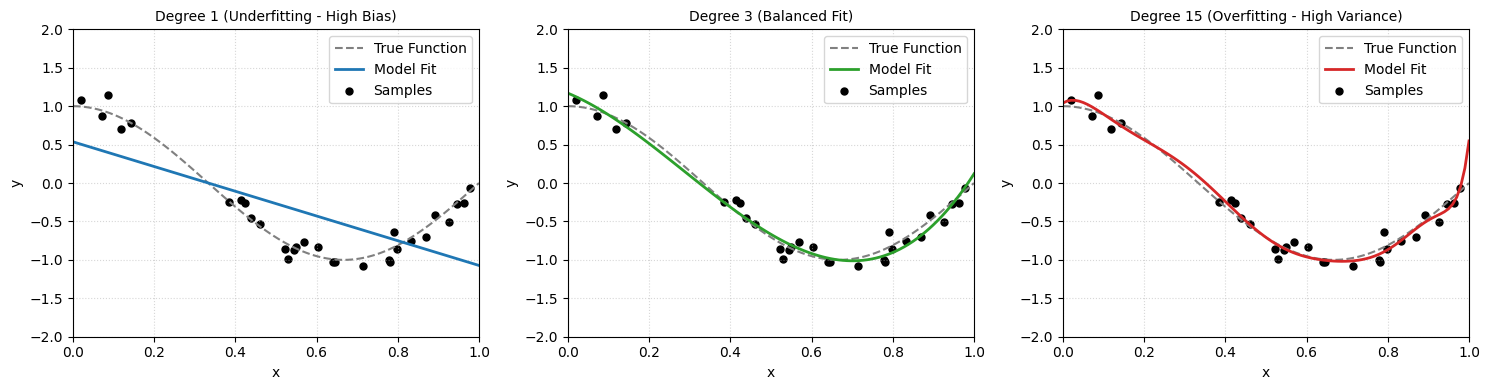

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 1. Generate synthetic dataset with true cosine wave function + noise
np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))
y = np.cos(1.5 * np.pi * X) + np.random.randn(n_samples) * 0.1

# 2. Compare 3 distinct model degrees: 1 (underfit), 3 (good fit), and 15 (overfit)
degrees = [1, 3, 15]
titles = ['Degree 1 (Underfitting - High Bias)', 'Degree 3 (Balanced Fit)', 'Degree 15 (Overfitting - High Variance)']
colors = ['tab:blue', 'tab:green', 'tab:red']

plt.figure(figsize=(15, 4))
X_test = np.linspace(0, 1, 100)

for i, (deg, title, color) in enumerate(zip(degrees, titles, colors)):
    ax = plt.subplot(1, len(degrees), i + 1)
    poly_reg = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    poly_reg.fit(X[:, np.newaxis], y)
    
    # Plot true function, observations, and fitted model curve
    plt.plot(X_test, np.cos(1.5 * np.pi * X_test), label='True Function', color='gray', linestyle='--')
    plt.plot(X_test, poly_reg.predict(X_test[:, np.newaxis]), label='Model Fit', color=color, linewidth=2)
    plt.scatter(X, y, edgecolors='k', s=25, label='Samples', color='black')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc='best')
    plt.title(title, fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()